In [ ]:
import os
import json
import sys
from tempfile import mkdtemp

from imblearn.over_sampling import ADASYN, SMOTE

# make lib/ importable from the notebooks/ directory
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import pandas as pd
import pydicom
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, Normalizer
from lib import label_images

DATA_DIR = "../data"
LABELS_CSV = DATA_DIR + "/labels.csv"
CACHE_FILE = DATA_DIR + "/split_cache.npz"
IMG_SIZE = (64, 64)
CROP_FRAC = 0.80  # keep central 80% of each axis → drops ~10% border on each side

if not os.path.exists(LABELS_CSV):
    label_images.main()

df = pd.read_csv(LABELS_CSV)


In [3]:

def load_dicom(path, size=IMG_SIZE, crop_frac=CROP_FRAC):
    ds = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    # center crop — removes border text/watermarks
    h, w = arr.shape
    ch, cw = int(h * crop_frac), int(w * crop_frac)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    arr = arr[y0:y0+ch, x0:x0+cw]
    # resize and flatten
    img = Image.fromarray((arr * 255).astype(np.uint8)).resize(size)
    return np.array(img).flatten()

# NOTE: delete data/split_cache.npz whenever CROP_FRAC changes — the cache
# stores flattened pixels and will be stale if the crop parameters differ.
if os.path.exists(CACHE_FILE):
    print(f"Loading split from cache: {CACHE_FILE}")
    print(f"  (cached with CROP_FRAC={CROP_FRAC} — delete cache if this changed)")
    cache = np.load(CACHE_FILE)
    X_train, X_test, y_train, y_test = cache["X_train"], cache["X_test"], cache["y_train"], cache["y_test"]
else:
    df = pd.read_csv(LABELS_CSV)
    print(f"Total images: {len(df)}  |  sick: {(df.label==1).sum()}  |  not_sick: {(df.label==0).sum()}")
    print(f"CROP_FRAC={CROP_FRAC}  IMG_SIZE={IMG_SIZE}")

    print("Loading images...")
    X = np.array([load_dicom(p) for p in df["dicom_path"]])
    y = df["label"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    np.savez_compressed(CACHE_FILE, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
    print(f"Split cached to: {CACHE_FILE}")

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


Total images: 29916  |  sick: 9247  |  not_sick: 20669
CROP_FRAC=0.8  IMG_SIZE=(64, 64)
Loading images...
Split cached to: data/split_cache.npz
X_train: (23932, 4096)  |  X_test: (5984, 4096)


In [4]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import Normalizer
from imblearn.over_sampling import SMOTE

memory = mkdtemp()
pipeline = Pipeline([
    ('normalizer', Normalizer()),
    ('pca', PCA(n_components=0.95)),
    ('smt', SMOTE()),
    ('knn', KNeighborsClassifier(n_jobs=-1)),
], memory=memory)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.61      0.71      4134
           1       0.47      0.77      0.59      1850

    accuracy                           0.66      5984
   macro avg       0.66      0.69      0.65      5984
weighted avg       0.74      0.66      0.67      5984



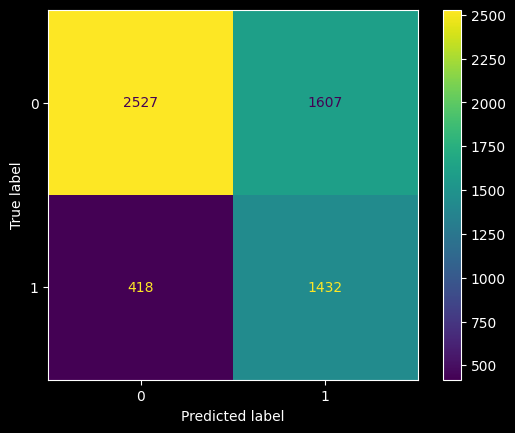

In [5]:
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()